**Implementación de modelos supervisados (clasificación y regresión) con Scikit-learn.**

El propósito de este notebook es la implementación de modelos predictivos supervisados utilizando la librería Scikit-learn, aplicados al análisis de un conjunto de datos de clientes.

El documento está diseñado para cubrir el flujo de trabajo  de Machine Learning:

* Preprocesamiento y construcción de pipelines: El notebook demuestra cómo se realiza la limpieza de datos (tratamiento de valores atípicos, negativos y nulos) y la construcción de pipelines de transformación para procesar variables numéricas, categóricas nominales y ordinales.
* Modelos de Regresión: Aborda el entrenamiento y la evaluación de algoritmos Regresión Lineal y Árboles de Decisión para predecir una variable numérica continua, utilizando como caso de uso la predicción del gasto mensual de los clientes.
* Modelos de Clasificación: Se enfoca en la predicción de variables categóricas mediante la implementación de algoritmos de Regresión Logística, Árboles de Decisión (Decision Tree Classifier) y Máquinas de Vectores de Soporte (SVM) para predecir la probabilidad de abandono de los usuarios.
* Evaluación: El documento incluye la validación de los modelos utilizando diversas métricas de rendimiento y el guardado local de los modelos y datos de prueba a través de la librería "joblib" para un uso futuro.

### Requisitos de software: este notebook fue desarrollado usando Python 3.14 y las siguientes librerías necesarias:

* pandas 3.0.2
* matplotlib 3.10.9
* scikit-learn (sklearn) 1.8.0
* joblib 1.5.3

### Importe de librerías necesarias


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree


In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from preprocesamiento.data_preprocessing import corregir_valores_negativos
from preprocesamiento.data_preprocessing import detectar_inconsistencias
from preprocesamiento.data_preprocessing import separar_objetivo_features
from preprocesamiento.data_preprocessing import eliminar_nulos_objetivo
from preprocesamiento.pipelines import aplicar_pipeline_limpieza_train_test
from preprocesamiento.pipelines import build_cleaning_pipeline_reg
from preprocesamiento.pipelines import build_cleaning_pipeline
from preprocesamiento.pipelines import build_decision_tree_classifier_pipeline
from preprocesamiento.pipelines import build_decision_tree_regressor_pipeline
from preprocesamiento.pipelines import build_linear_regression_pipeline
from preprocesamiento.pipelines import build_logistic_regression_classifier_pipeline
from preprocesamiento.pipelines import build_preprocessor
from preprocesamiento.pipelines import build_svm_classifier_pipeline
from model_evaluation import evaluar_regresor
from model_evaluation import evaluar_classifier
from model_training import entrenar_modelo
from model_evaluation import graficar_matriz_confusion

### Carga de Datos

In [3]:
url = "https://raw.githubusercontent.com/ramirezluna-david/proyecto_modelado_grp2/rama_david/data/dataset_clientes.csv"
data = pd.read_csv(url)

### Preprocesamiento de datos

#### Detección de inconsistencias

In [4]:
# Detección de inconsistencias: valores negativos o ceros en columnas que deberían ser positivas.
conteo_negativos, conteo_ceros = detectar_inconsistencias(data)

Negativos detectados: {'ingreso_mensual': 11, 'gasto_mensual': 68, 'deuda_total': 143}
Ceros detectados: ninguno


In [5]:
# Tratamiento: corrige valores negativos convirtiéndolos a valores absolutos.
data = corregir_valores_negativos(data)

Valores negativos corregidos a valores absolutos en las columnas relevantes.


# 1. Modelamiento para variable objetivo "gasto_mensual"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [6]:
data_filtrada = eliminar_nulos_objetivo(data, target="gasto_mensual")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="gasto_mensual",
 )

In [7]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [8]:
numerical_features = ["deuda_total", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [9]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression para "gasto_mensual"

### Pipeline para Regresión Lineal

In [10]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [11]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29
)

# Ajusta el pipeline solo con el conjunto de entrenamiento y transforma ambos conjuntos.
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,deuda_total,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.397639,-0.194112,-0.177909,0.533434,0.838486,-0.915482,-0.574637,0.002288,0.803048,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
1,0.434478,0.290352,-0.389698,-0.697633,-0.357178,0.736145,-1.724756,-1.417333,-0.067703,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.608634,0.813164,-1.146468,1.037052,-0.473828,0.002089,0.689545,-1.417333,1.673799,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-1.772833,-0.579034,-0.973814,-1.704869,-0.969591,1.286687,-1.439603,1.421909,-0.067703,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
4,-0.545305,1.190941,-0.186973,-0.305930,0.021935,0.919659,1.345398,-0.707522,1.673799,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [12]:
target = "gasto_mensual"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1",
    "tipo_plan",
    "dia_semana_registro_Viernes", 
    "region_Norte", 
    "canal_registro_App", 
    "dia_semana_registro_Jueves",
    "uso_app",
    "estado_civil_Soltero",
    "region_Sur"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [13]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((15200, 10), (3800, 10))

### Entrenamiento


In [14]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [15]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : 0.001
MAE   : 119,185


In [16]:
# Variables eliminadas por colinealidad.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [17]:
# Variables con las que se entrenó el modelo.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=9):
- abandono_0
- tipo_plan
- dia_semana_registro_Viernes
- region_Norte
- canal_registro_App
- dia_semana_registro_Jueves
- uso_app
- estado_civil_Soltero
- region_Sur


## Modelo DecisionTreeRegressor para "gasto_mensual"

### Pipeline para DecisionTreeRegressor

In [18]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [19]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29
)

# Ajusta el pipeline solo con el conjunto de entrenamiento y transforma ambos conjuntos.
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,deuda_total,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.397639,-0.194112,-0.177909,0.533434,0.838486,-0.915482,-0.574637,0.002288,0.803048,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
1,0.434478,0.290352,-0.389698,-0.697633,-0.357178,0.736145,-1.724756,-1.417333,-0.067703,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.608634,0.813164,-1.146468,1.037052,-0.473828,0.002089,0.689545,-1.417333,1.673799,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-1.772833,-0.579034,-0.973814,-1.704869,-0.969591,1.286687,-1.439603,1.421909,-0.067703,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
4,-0.545305,1.190941,-0.186973,-0.305930,0.021935,0.919659,1.345398,-0.707522,1.673799,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [20]:
target = "gasto_mensual"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1",
    "tipo_plan",
    "dia_semana_registro_Viernes", 
    "region_Norte", 
    "canal_registro_App", 
    "dia_semana_registro_Jueves",
    "uso_app",
    "estado_civil_Soltero",
    "region_Sur"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [21]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((15200, 10), (3800, 10))

### Entrenamiento

In [22]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [23]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : -0.015
MAE   : 120,487


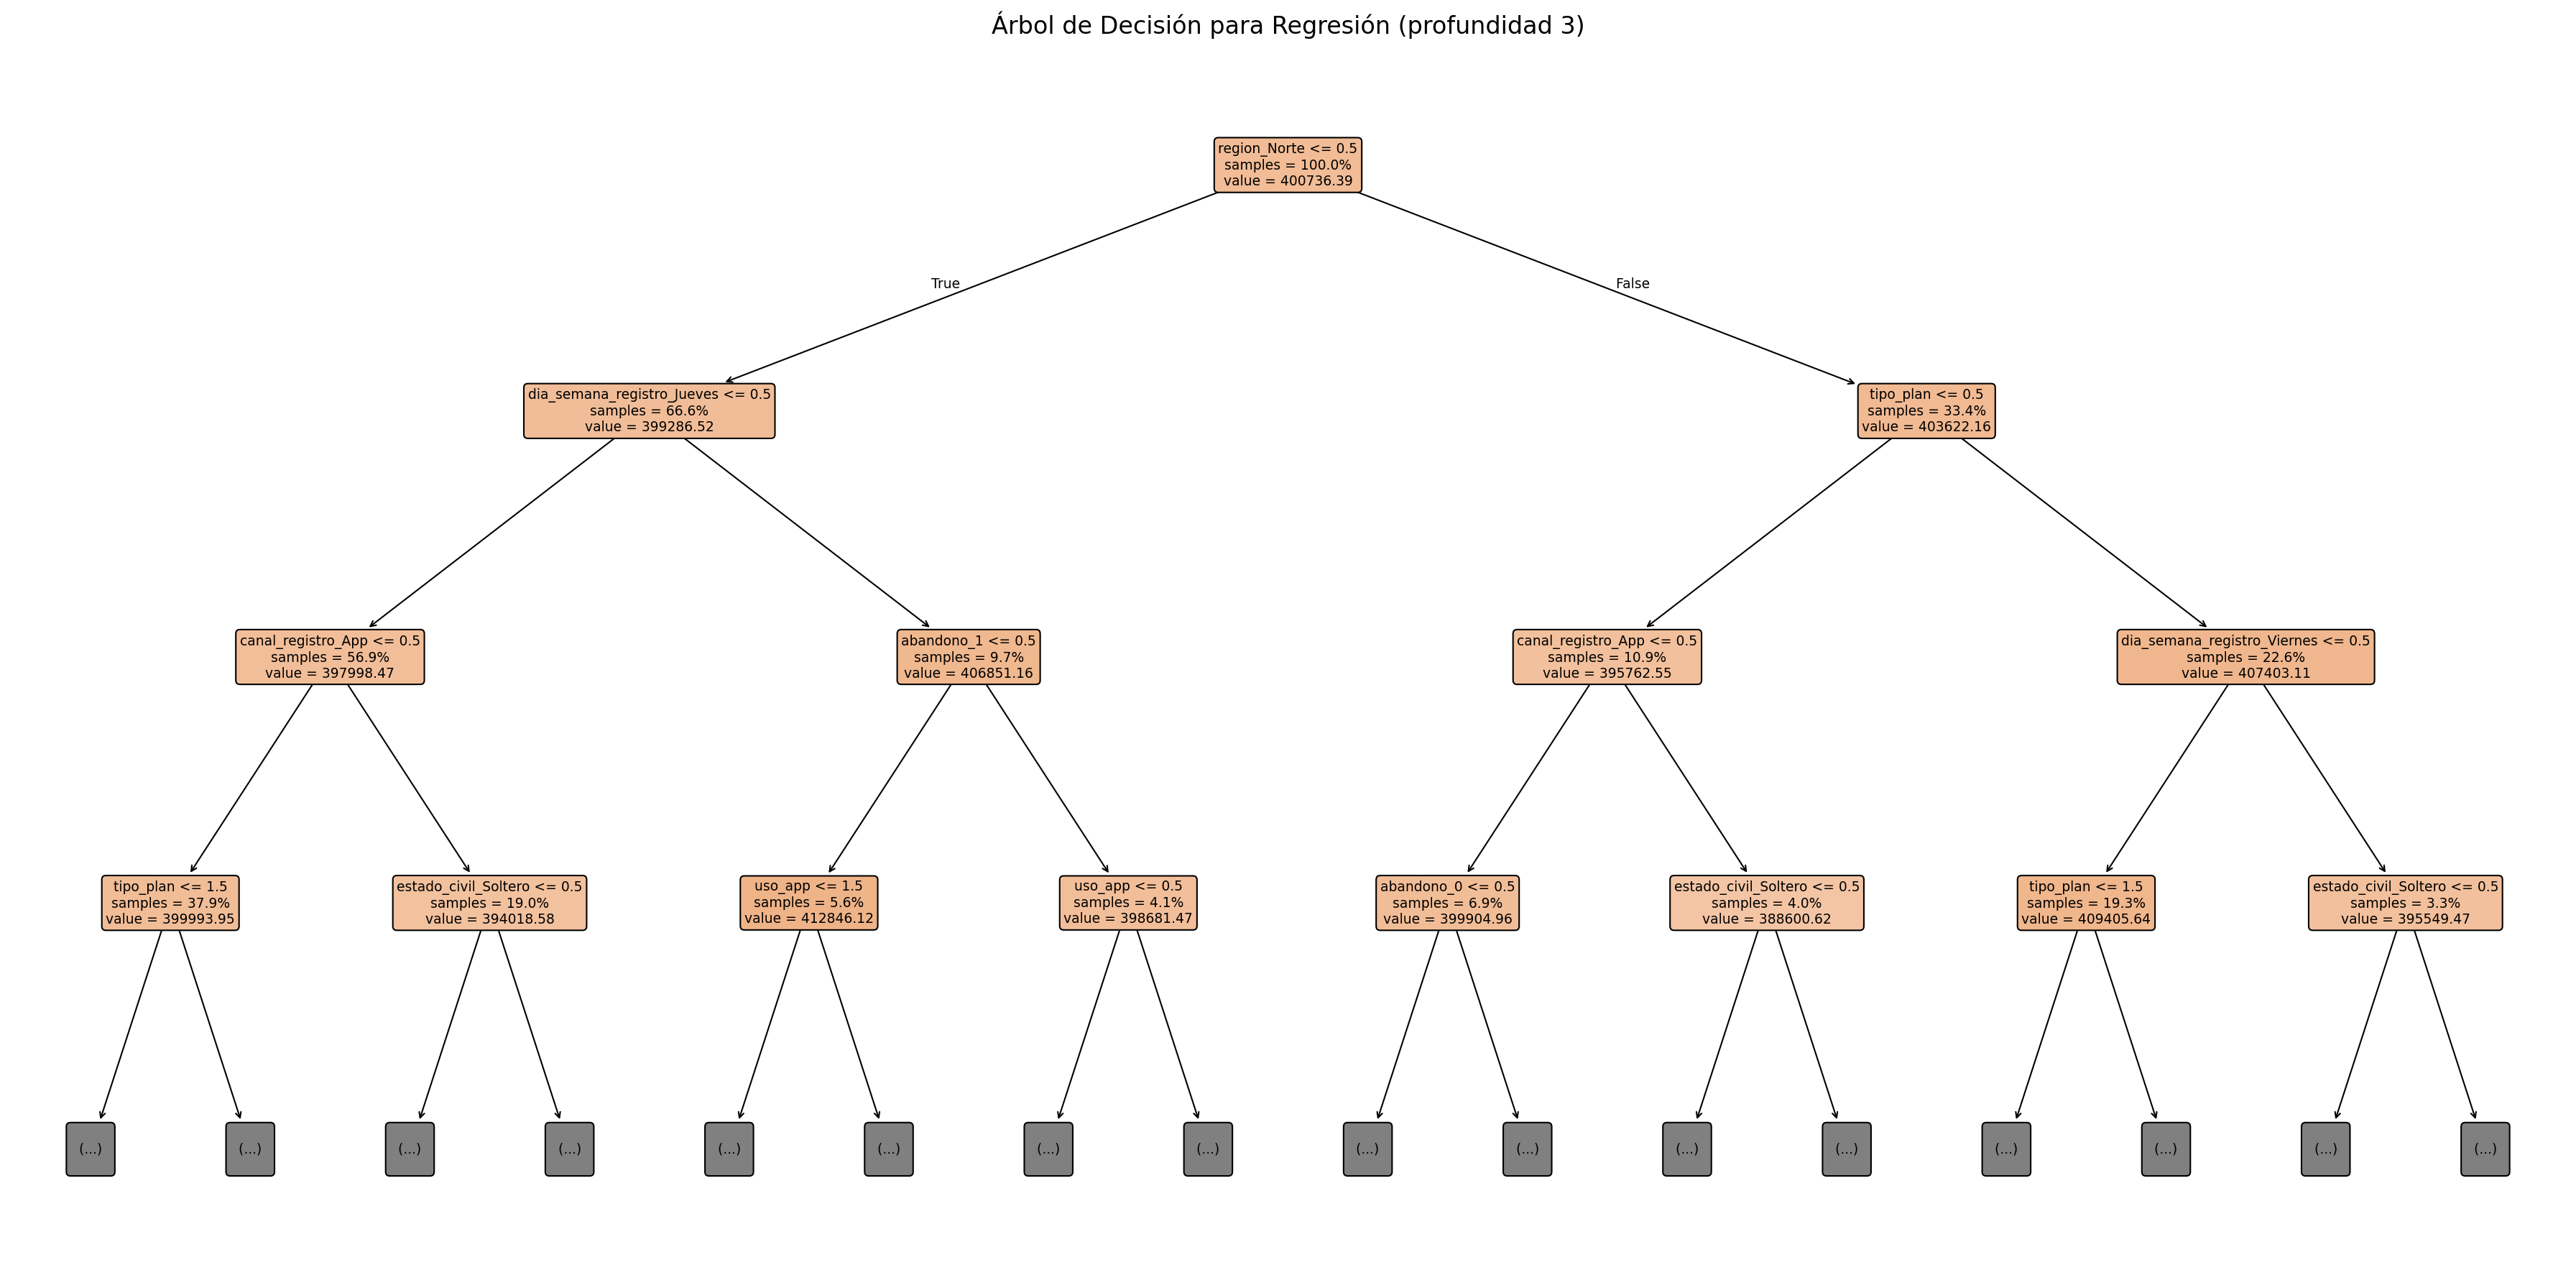

In [24]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

In [25]:
base_dir = project_root if "project_root" in globals() else Path.cwd().resolve()

models_dir = base_dir / "models"
processed_dir = base_dir / "data" / "processed"
models_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

# Guarda los pipelines de regresión entrenados
joblib.dump(pipeline_modelo_lr, models_dir / "pipeline_modelo_lr_reg.joblib")
joblib.dump(pipeline_modelo_dtr, models_dir / "pipeline_modelo_dtr_reg.joblib")

# Guarda los conjuntos de entrenamiento de regresión para asegurar consistencia
joblib.dump(X_train, processed_dir / "X_train_reg.joblib")
joblib.dump(y_train, processed_dir / "y_train_reg.joblib")

# Guarda los conjuntos de prueba de regresión para asegurar consistencia
joblib.dump(X_test, processed_dir / "X_test_reg.joblib")
joblib.dump(y_test, processed_dir / "y_test_reg.joblib")

print("Modelos y datos de regresión guardados")

Modelos y datos de regresión guardados


# 2. Modelamiento para variable objetivo "abandono"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [26]:
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data,
    target="abandono",
 )

## Construcción de arrays para procesamiento

In [27]:
numerical_features = ['deuda_total','porcentaje_gasto',"ratio_endeudamiento", "gasto_mensual", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas
categorical_nominales = [ "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro","dia_semana_registro"] # Define listado de variables categóricas nominales
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora
orden_tipo_plan = ['Basico', 'Estandar', 'Premium'] # Define orden para variable ordinal tipo_plan
orden_uso_app = ['Bajo', 'Medio', 'Alto'] # Define orden para variable ordinal uso_app

## Integración de pipelines de transformación

In [28]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LogisticRegression para objetivo "abandono"

### Pipeline para LogisticRegression

In [29]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline(preprocesador)

# Define el pipeline para regresión logística.
pipeline_modelo_lr = build_logistic_regression_classifier_pipeline(
    max_iter=1000,
    class_weight="balanced",
    threshold=0.9,
)

In [30]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29, stratify=var_dep
)

# Ajusta el pipeline solo con el conjunto de entrenamiento y transforma ambos conjuntos.
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,deuda_total,porcentaje_gasto,ratio_endeudamiento,gasto_mensual,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,0.059457,-0.339402,0.058175,-2.058851,0.696549,-0.579710,0.029932,-1.274163,1.652707,0.877376,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.009551,0.217818,0.285275,-0.237297,0.553744,-1.026655,-1.702631,-0.510853,0.920271,-1.376108,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
2,1.603115,-0.063094,0.092257,0.374751,0.571964,0.114277,-1.646742,-1.215447,1.286489,-0.948232,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,1.851427,-0.058666,0.047836,1.069735,0.000000,0.571286,-0.976073,1.456140,-0.178382,0.497041,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.300905,0.109693,-0.216858,2.460333,-0.017379,0.486508,-0.528959,0.046951,1.103380,-0.178053,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [31]:
target = "abandono"
mejores_variables_predictoras = [
    'ultima_compra_dias',
    'uso_app',
    'tipo_plan',
    'frecuencia_compra',
    'deuda_total',
    'score_crediticio',
    'ratio_endeudamiento',
    'dia_semana_registro_Viernes',
    'region_Norte',
    'dia_semana_registro_Jueves',
    'region_Sur','gasto_mensual',
    'dia_semana_registro_Miercoles',
    'dia_semana_registro_Lunes'
]

X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test

In [32]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((16000, 14), (4000, 14))

### Entrenamiento

In [33]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [34]:
# Predicciones y evaluación.
metricas = evaluar_classifier(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'Accuracy':<20}: {metricas['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas['roc_auc']:.4f}")


--- Métricas del modelo ---
Accuracy            : 0.6240
F1 Score:           : 0.5671
ROC AUC Score       : 0.6751


In [35]:
# Predicciones
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.61775
Score del modelo en test                :0.62400


In [36]:
# Variables eliminadas por colinealidad.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=0):


In [37]:
# Variables con las que se entrenó el modelo.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=14):
- ultima_compra_dias
- uso_app
- tipo_plan
- frecuencia_compra
- deuda_total
- score_crediticio
- ratio_endeudamiento
- dia_semana_registro_Viernes
- region_Norte
- dia_semana_registro_Jueves
- region_Sur
- gasto_mensual
- dia_semana_registro_Miercoles
- dia_semana_registro_Lunes


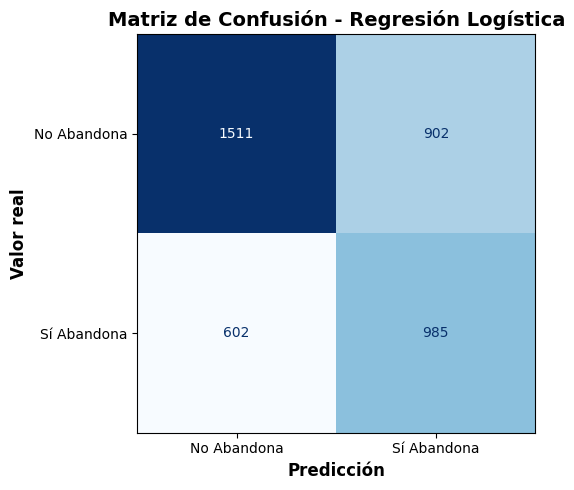

In [38]:
# Graficar Matriz de confusión para modelo Regresión Logística
graficar_matriz_confusion(
    modelo = pipeline_modelo_lr, 
    X_test = X_test, 
    y_test = y_test, 
    clases=["No Abandona", "Sí Abandona"], 
    titulo="Matriz de Confusión - Regresión Logística"
)

## Modelo de DecisionTreeClassifier para objetivo "abandono"

In [39]:
# Define el pipeline para DecisionTreeClassifier.
pipeline_modelo_dtc = build_decision_tree_classifier_pipeline(
    max_depth=5,
    class_weight="balanced",
    min_samples_leaf=1,
    min_samples_split=2,
    threshold=0.9,
)

### División train/test

In [40]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((16000, 14), (4000, 14))

### Entrenamiento

In [41]:
pipeline_modelo_dtc = entrenar_modelo(pipeline_modelo_dtc, X_train, y_train)

In [42]:
# Predicciones y evaluación.
metricas = evaluar_classifier(pipeline_modelo_dtc, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'Accuracy':<20}: {metricas['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas['roc_auc']:.4f}")


--- Métricas del modelo ---
Accuracy            : 0.6268
F1 Score:           : 0.5626
ROC AUC Score       : 0.6691


In [43]:
# Predicciones
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_dtc.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_dtc.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.63038
Score del modelo en test                :0.62675


In [44]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_dtc.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=0):


In [45]:
# Variables con las que se entrenó el modelo.
cols_eliminadas = pipeline_modelo_dtc.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=14):
- ultima_compra_dias
- uso_app
- tipo_plan
- frecuencia_compra
- deuda_total
- score_crediticio
- ratio_endeudamiento
- dia_semana_registro_Viernes
- region_Norte
- dia_semana_registro_Jueves
- region_Sur
- gasto_mensual
- dia_semana_registro_Miercoles
- dia_semana_registro_Lunes


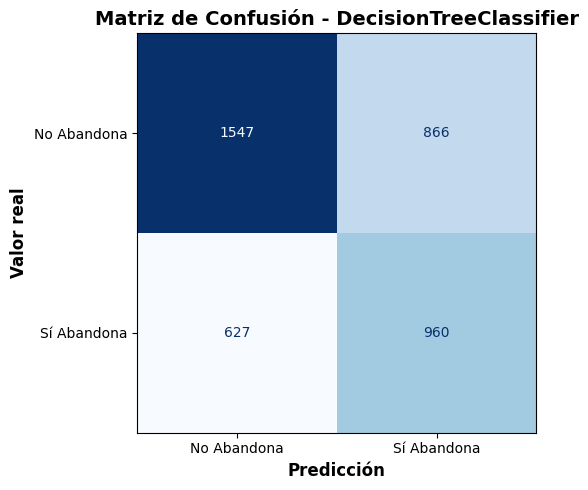

In [46]:
# Graficar Matriz de confusión para modelo DecisionTreeClassifier
graficar_matriz_confusion(
    modelo = pipeline_modelo_dtc, 
    X_test = X_test, 
    y_test = y_test, 
    clases=["No Abandona", "Sí Abandona"], 
    titulo="Matriz de Confusión - DecisionTreeClassifier"
)

## Modelo de SVM para objetivo "abandono"

In [47]:
# Define el pipeline para SVM.
pipeline_modelo_svm = build_svm_classifier_pipeline(
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=42,
    threshold=0.9,
)

### División train/test

In [48]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((16000, 14), (4000, 14))

### Entrenamiento

In [49]:
pipeline_modelo_svm = entrenar_modelo(pipeline_modelo_svm, X_train, y_train)

In [50]:
# Predicciones y evaluación.
metricas = evaluar_classifier(pipeline_modelo_svm, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'Accuracy':<20}: {metricas['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas['roc_auc']:.4f}")


--- Métricas del modelo ---
Accuracy            : 0.6230
F1 Score:           : 0.5667
ROC AUC Score       : 0.6691


In [51]:
# Predicciones
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_svm.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_svm.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.64338
Score del modelo en test                :0.62300


In [52]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_svm.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=0):


In [53]:
# Variables con las que se entrenó el modelo.
cols_eliminadas = pipeline_modelo_svm.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=14):
- ultima_compra_dias
- uso_app
- tipo_plan
- frecuencia_compra
- deuda_total
- score_crediticio
- ratio_endeudamiento
- dia_semana_registro_Viernes
- region_Norte
- dia_semana_registro_Jueves
- region_Sur
- gasto_mensual
- dia_semana_registro_Miercoles
- dia_semana_registro_Lunes


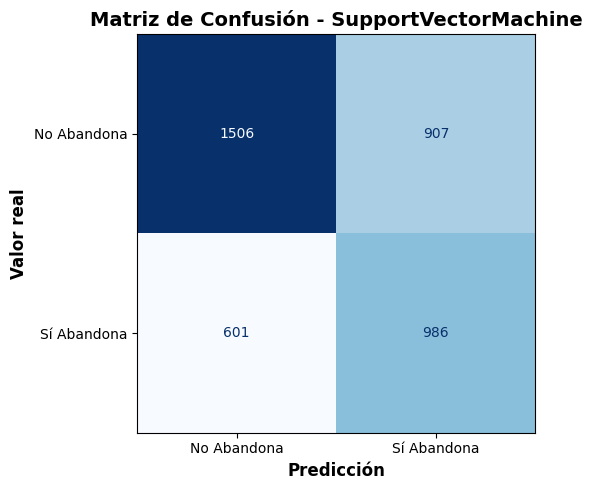

In [54]:
# Graficar Matriz de confusión para modelo SupportVectorMachine
graficar_matriz_confusion(
    modelo = pipeline_modelo_svm, 
    X_test = X_test, 
    y_test = y_test, 
    clases=["No Abandona", "Sí Abandona"], 
    titulo="Matriz de Confusión - SupportVectorMachine"
)

In [55]:
# Guarda los pipelines de clasificación entrenados
joblib.dump(pipeline_modelo_lr, models_dir / "pipeline_modelo_lr_clf.joblib")
joblib.dump(pipeline_modelo_dtc, models_dir / "pipeline_modelo_dtc_clf.joblib")
joblib.dump(pipeline_modelo_svm, models_dir / "pipeline_modelo_svm_clf.joblib")

# Guarda los conjuntos de prueba de clasificación
joblib.dump(X_test, processed_dir / "X_test_clf.joblib")
joblib.dump(y_test, processed_dir / "y_test_clf.joblib")

# Guarda los conjuntos de entrenamiento de clasificación para asegurar consistencia
joblib.dump(X_train, processed_dir / "X_train_clf.joblib")
joblib.dump(y_train, processed_dir / "y_train_clf.joblib")

print("Modelos y datos de clasificación guardados")

Modelos y datos de clasificación guardados
